<a href="https://colab.research.google.com/github/Rutwij12/nlp-cw/blob/main/NLP_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import ast

# 1. Define the column names based on your TSV structure
# The TSV appears to have no header, so we specify them manually
columns_x = ['par_id', 'semeval_id', 'keyword', 'country_code', 'text', 'original_label']

# Load the TSV file (ensure the file path is correct for your machine)
df_x = pd.read_csv('datasets/dontpatronizeme_pcl.tsv', sep='\t', header=None, names=columns_x, skiprows=4)

print(df_x.head())

# Load the CSV file
df_a = pd.read_csv('datasets/train_semeval_parids-labels.csv')

print(df_a.head())

# 2. Clean the par_id in df_x (remove '@@') and ensure both are strings for merging
# df_x['par_id'] = df_x['par_id'].astype(int)
# df_a['par_id'] = df_a['par_id'].astype(int)

# 3. Merge the datasets on 'par_id'
# We use a 'left' merge so we keep all rows from x.tsv even if they aren't in a.csv
df_merged = pd.merge(df_x, df_a, on='par_id', how='right')

# 4. Create the new binary label
def check_for_pcl(label_str):
    if pd.isna(label_str):
        # If there's no match in a.csv, we default to 0 (or you could return the 'original_label')
        return 0
    try:
        # literal_eval safely evaluates the string into a Python list
        categories = ast.literal_eval(label_str)
        # Return 1 if there is at least one '1' in the list, otherwise 0
        return 1 if 1 in categories else 0
    except:
        # Fallback for any parsing errors
        return 0

# Apply the function to create our new target column
df_merged['final_label'] = df_merged['label'].apply(check_for_pcl)

# (Optional) Drop the old confusing label columns to keep the dataset clean
df_merged = df_merged.drop(columns=['original_label', 'label'])

# 5. Save the transformed data
output_file = 'merged_pcl_dataset.csv'
df_merged.to_csv(output_file, index=False)

print(f"Data successfully joined and transformed! Saved to {output_file}.")
# Preview the first few rows
print(df_merged[['par_id', 'keyword', 'final_label']].head(10))

   par_id  semeval_id    keyword country_code  \
0       1  @@24942188   hopeless           ph   
1       2  @@21968160    migrant           gh   
2       3  @@16584954  immigrant           ie   
3       4   @@7811231   disabled           nz   
4       5   @@1494111    refugee           ca   

                                                text  original_label  
0  We 're living in times of absolute insanity , ...             0.0  
1  In Libya today , there are countless number of...             0.0  
2  White House press secretary Sean Spicer said t...             0.0  
3  Council customers only signs would be displaye...             0.0  
4  " Just like we received migrants fleeing El Sa...             0.0  
   par_id                  label
0    4341  [1, 0, 0, 1, 0, 0, 0]
1    4136  [0, 1, 0, 0, 0, 0, 0]
2   10352  [1, 0, 0, 0, 0, 1, 0]
3    8279  [0, 0, 0, 1, 0, 0, 0]
4    1164  [1, 0, 0, 1, 1, 1, 0]
Data successfully joined and transformed! Saved to merged_pcl_dataset.csv.
   par

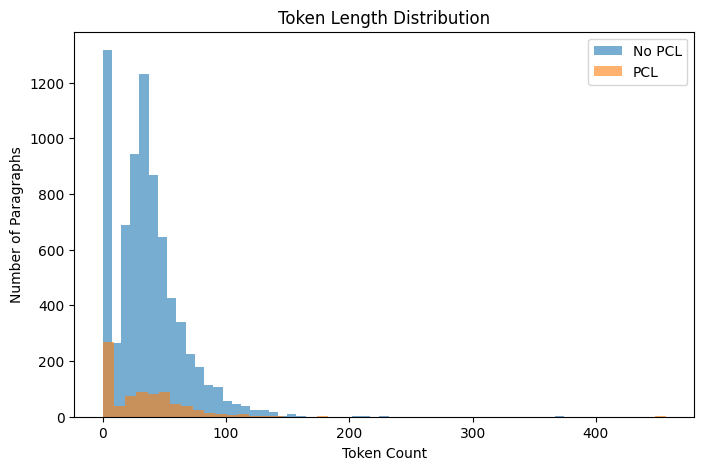

Vocabulary Size: 23488
Total Tokens: 296813
20 Most frequent words:  [('the', 17011), ('to', 9276), ('of', 9112), ('and', 8397), ('in', 7267), ('a', 6028), ('for', 3263), ('that', 3148), ('is', 2932), ('s', 2303), ('are', 2224), ('on', 2133), ('with', 1992), ('as', 1990), ('it', 1703), ('from', 1692), ('was', 1535), ('have', 1530), ('by', 1482), ('be', 1480)]
y
0    7581
1     794
Name: count, dtype: int64
y
0    90.519403
1     9.480597
Name: proportion, dtype: float64
        Class  Count  Percentage
0  No PCL (0)   7581   90.519403
1     PCL (1)    794    9.480597


<Figure size 600x400 with 0 Axes>

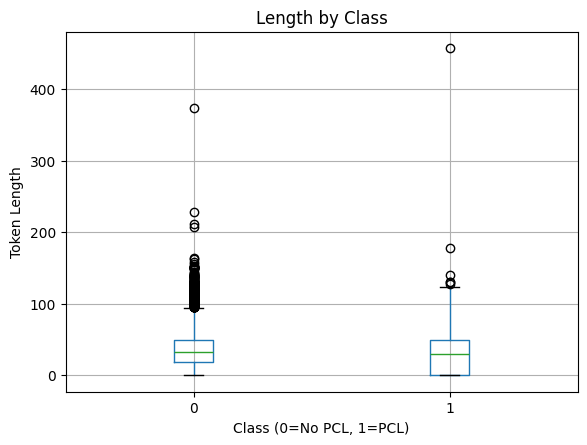

In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from collections import Counter

# Load dataset
df = pd.read_csv('merged_pcl_dataset.csv')

df['y'] = (df['final_label'] == 1).astype(int)

######## TOKEN COUNT ANALYSIS #######
TOKEN_RE = re.compile(r"[a-z]+(?:'[a-z]+)?")

def tokenize(text):
    if not isinstance(text, str):
        return []
    return TOKEN_RE.findall(text.lower())

df['tokens'] = df['text'].apply(tokenize)
df['length'] = df['tokens'].apply(len)

token_stats = {
    "mean_length": df["length"].mean(),
    "median_length": df["length"].median(),
    "min_length": df["length"].min(),
    "max_length": df["length"].max(),
    "p95_length": df["length"].quantile(0.95)
}

plt.figure(figsize=(8,5))

plt.hist(df[df["y"]==0]["length"],
         bins=50,
         alpha=0.6,
         label="No PCL")

plt.hist(df[df["y"]==1]["length"],
         bins=50,
         alpha=0.6,
         label="PCL")

plt.xlabel("Token Count")
plt.ylabel("Number of Paragraphs")
plt.title("Token Length Distribution")
plt.legend()

plt.savefig("length_distribution.pdf")
plt.show()


######## Vocabulary Size Analysis #######

all_tokens = [token for tokens in df['tokens'] for token in tokens]
vocab = set(all_tokens)
vocab_size = len(vocab)
total_tokens = len(all_tokens)
print(f"Vocabulary Size: {vocab_size}")
print(f"Total Tokens: {total_tokens}")

# Most frequent words
print("20 Most frequent words: ", Counter(all_tokens).most_common(20))


######## Class Distribution #######

class_counts = df["y"].value_counts().sort_index()

print(class_counts)

class_percent = df["y"].value_counts(normalize=True)*100
print(class_percent)

class_table = pd.DataFrame({
    "Class":["No PCL (0)","PCL (1)"],
    "Count":[class_counts[0], class_counts[1]],
    "Percentage":[class_percent[0], class_percent[1]]
})

print(class_table)

plt.figure(figsize=(6,4))
df.boxplot(column="length", by="y")
plt.title("Length by Class")
plt.suptitle("")
plt.xlabel("Class (0=No PCL, 1=PCL)")
plt.ylabel("Token Length")

plt.savefig("length_boxplot.pdf")
plt.show()


===== DUPLICATE DETECTION =====

Exact Text Duplicates: 1503 rows
  Unique duplicate texts: 1502

Sample duplicate texts:

Checking for duplicates with conflicting labels:

===== SPECIAL CHARACTERS & HTML DETECTION =====

HTML/Special Character Patterns Found:
  amp: 40 rows (0.48%)
  lt: 0 rows (0.00%)
  gt: 14 rows (0.17%)
  quot: 0 rows (0.00%)
  apos: 0 rows (0.00%)
  html_tags: 253 rows (3.02%)
  newlines: 0 rows (0.00%)
  tabs: 0 rows (0.00%)
  unicode_escapes: 0 rows (0.00%)

Punctuation Statistics:
  Mean punctuation density: 0.0239
  Max punctuation density: 0.1078
  Rows with >50% punctuation: 0

Non-ASCII Characters:
  Rows with non-ASCII: 0 (0.00%)

===== OUTLIER DETECTION =====

Token Count Statistics:
  Mean: 35.44
  Median: 33.00
  Std Dev: 28.06
  Min: 0
  Max: 457
  Q1 (25%): 18.00
  Q3 (75%): 49.00

Outliers (IQR method):
  Lower bound: -28.50 tokens
  Upper bound: 95.50 tokens
  Total outliers: 286 rows (3.41%)

Very Short Texts (<5 tokens): 1520 rows (18.15%)
  Exa

/tmp/ipython-input-195/3302583560.py:162: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_to_plot, labels=['No PCL', 'PCL'], patch_artist=True)


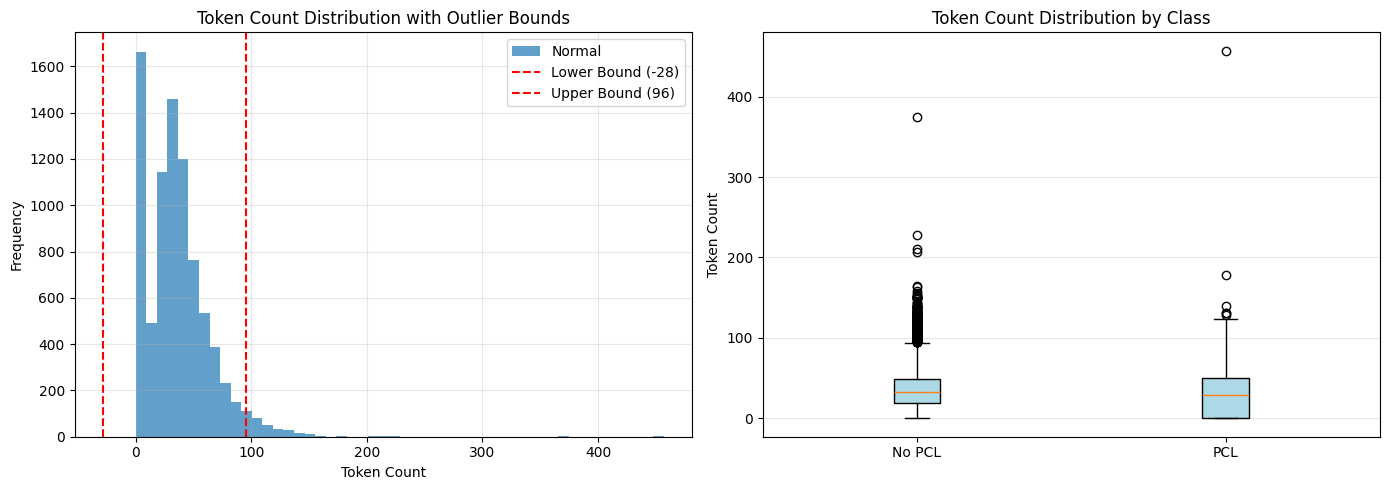


===== NOISE SUMMARY REPORT =====

Total Records: 8375

1. DUPLICATES:
   - Exact duplicates: 1502

2. SPECIAL CHARACTERS/HTML:
   - Non-ASCII rows: 0
   - High punctuation (>50%): 0

3. OUTLIERS:
   - Length outliers: 286
   - Very short (<5 tokens): 1520
   - Very long (>200 tokens): 5

Outliers saved to: outliers_detected.csv


In [3]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from collections import Counter

# Load dataset
df = pd.read_csv('merged_pcl_dataset.csv')
df['y'] = (df['final_label'] >= 1).astype(int)

######## DUPLICATES #######

print("\n===== DUPLICATE DETECTION =====")

# Check for exact text duplicates
exact_duplicates = df[df.duplicated(subset=['text'], keep=False)]
num_exact_duplicates = len(exact_duplicates)
print(f"\nExact Text Duplicates: {num_exact_duplicates} rows")
print(f"  Unique duplicate texts: {df['text'].duplicated().sum()}")

if num_exact_duplicates > 0:
    print("\nSample duplicate texts:")
    dup_texts = df['text'].value_counts()
    dup_texts = dup_texts[dup_texts > 1]
    for text, count in dup_texts.head(5).items():
        print(f"  '{text[:80]}...' appears {count} times")

# Check for near-duplicates (same text with different labels)
print("\nChecking for duplicates with conflicting labels:")
for text, group in df.groupby('text'):
    if len(group['y'].unique()) > 1:
        print(f"  Conflicting labels for: '{text[:80]}...'")
        print(f"    Labels: {group['y'].unique()}")
        break

######## SPECIAL CHARACTERS & HTML #######

print("\n===== SPECIAL CHARACTERS & HTML DETECTION =====")

# Common HTML entities and special patterns
html_patterns = {
    'amp': r'&amp;',
    'lt': r'&lt;',
    'gt': r'&gt;',
    'quot': r'&quot;',
    'apos': r'&apos;',
    'html_tags': r'<[^>]+>',
    'newlines': r'\\n|\n',
    'tabs': r'\\t|\t',
    'unicode_escapes': r'\\u[0-9a-fA-F]{4}',
}

print("\nHTML/Special Character Patterns Found:")
for pattern_name, pattern in html_patterns.items():
    count = df['text'].str.contains(pattern, regex=True, na=False).sum()
    percentage = (count / len(df)) * 100
    print(f"  {pattern_name}: {count} rows ({percentage:.2f}%)")

    if count > 0 and count <= 5:
        print(f"    Examples:")
        examples = df[df['text'].str.contains(pattern, regex=True, na=False)]['text'].head(3)
        for ex in examples:
            print(f"      '{ex[:80]}...'")

# Check for excessive punctuation
def count_punctuation(text):
    if not isinstance(text, str):
        return 0
    return len(re.findall(r'[!?.,;:\-\(\)\[\]{}\"\'\/\\@#$%^&*+=]', text))

df['punctuation_count'] = df['text'].apply(count_punctuation)
df['punctuation_density'] = df['punctuation_count'] / df['text'].str.len()

print(f"\nPunctuation Statistics:")
print(f"  Mean punctuation density: {df['punctuation_density'].mean():.4f}")
print(f"  Max punctuation density: {df['punctuation_density'].max():.4f}")
print(f"  Rows with >50% punctuation: {(df['punctuation_density'] > 0.5).sum()}")

# Check for non-ASCII characters
def has_non_ascii(text):
    if not isinstance(text, str):
        return False
    return any(ord(char) > 127 for char in text)

non_ascii_count = df['text'].apply(has_non_ascii).sum()
print(f"\nNon-ASCII Characters:")
print(f"  Rows with non-ASCII: {non_ascii_count} ({(non_ascii_count/len(df)*100):.2f}%)")

######## OUTLIERS #######

print("\n===== OUTLIER DETECTION =====")

# Text length analysis
df['text_length'] = df['text'].str.len()

TOKEN_RE = re.compile(r"[a-z]+(?:'[a-z]+)?")

def tokenize(text):
    if not isinstance(text, str):
        return []
    return TOKEN_RE.findall(text.lower())

df['tokens'] = df['text'].apply(tokenize)
df['token_count'] = df['tokens'].apply(len)

print(f"\nToken Count Statistics:")
print(f"  Mean: {df['token_count'].mean():.2f}")
print(f"  Median: {df['token_count'].median():.2f}")
print(f"  Std Dev: {df['token_count'].std():.2f}")
print(f"  Min: {df['token_count'].min()}")
print(f"  Max: {df['token_count'].max()}")
print(f"  Q1 (25%): {df['token_count'].quantile(0.25):.2f}")
print(f"  Q3 (75%): {df['token_count'].quantile(0.75):.2f}")

# IQR-based outlier detection
Q1 = df['token_count'].quantile(0.25)
Q3 = df['token_count'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['token_count'] < lower_bound) | (df['token_count'] > upper_bound)]
print(f"\nOutliers (IQR method):")
print(f"  Lower bound: {lower_bound:.2f} tokens")
print(f"  Upper bound: {upper_bound:.2f} tokens")
print(f"  Total outliers: {len(outliers)} rows ({(len(outliers)/len(df)*100):.2f}%)")

# Short texts (< 5 tokens)
short_texts = df[df['token_count'] < 5]
print(f"\nVery Short Texts (<5 tokens): {len(short_texts)} rows ({(len(short_texts)/len(df)*100):.2f}%)")
if len(short_texts) > 0:
    print(f"  Examples:")
    for text in short_texts['text'].head(5):
        print(f"    '{text}'")

# Long texts (> 200 tokens)
long_texts = df[df['token_count'] > 200]
print(f"\nVery Long Texts (>200 tokens): {len(long_texts)} rows ({(len(long_texts)/len(df)*100):.2f}%)")
if len(long_texts) > 0:
    print(f"  Sample long text length: {long_texts['token_count'].iloc[0]} tokens")

# Class-wise outlier analysis
print(f"\nOutlier Distribution by Class:")
print(f"  Class 0 (No PCL) outliers: {len(outliers[outliers['y']==0])} / {(outliers['y']==0).sum()}")
print(f"  Class 1 (PCL) outliers: {len(outliers[outliers['y']==1])} / {(outliers['y']==1).sum()}")

# Visualize token count distribution with outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with outliers highlighted
axes[0].hist(df['token_count'], bins=50, alpha=0.7, label='Normal')
axes[0].axvline(lower_bound, color='r', linestyle='--', label=f'Lower Bound ({lower_bound:.0f})')
axes[0].axvline(upper_bound, color='r', linestyle='--', label=f'Upper Bound ({upper_bound:.0f})')
axes[0].set_xlabel('Token Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Token Count Distribution with Outlier Bounds')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot by class
data_to_plot = [df[df['y']==0]['token_count'], df[df['y']==1]['token_count']]
bp = axes[1].boxplot(data_to_plot, labels=['No PCL', 'PCL'], patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
axes[1].set_ylabel('Token Count')
axes[1].set_title('Token Count Distribution by Class')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('outlier_detection.pdf')
plt.show()

######## SUMMARY REPORT #######

print("\n===== NOISE SUMMARY REPORT =====")
print(f"\nTotal Records: {len(df)}")
print(f"\n1. DUPLICATES:")
print(f"   - Exact duplicates: {df['text'].duplicated().sum()}")
print(f"\n2. SPECIAL CHARACTERS/HTML:")
print(f"   - Non-ASCII rows: {non_ascii_count}")
print(f"   - High punctuation (>50%): {(df['punctuation_density'] > 0.5).sum()}")
print(f"\n3. OUTLIERS:")
print(f"   - Length outliers: {len(outliers)}")
print(f"   - Very short (<5 tokens): {len(short_texts)}")
print(f"   - Very long (>200 tokens): {len(long_texts)}")

# Save outlier info to CSV for further inspection
if len(outliers) > 0:
    outliers_to_inspect = outliers[['text', 'token_count', 'final_label', 'y']].copy()
    outliers_to_inspect.to_csv('outliers_detected.csv', index=False)
    print(f"\nOutliers saved to: outliers_detected.csv")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.



===== N-GRAM ANALYSIS =====

Top 20 Bigrams:
[(('of', 'the'), 1760), (('in', 'the'), 1634), (('to', 'the'), 882), (('in', 'need'), 673), (('poor', 'families'), 593), (('for', 'the'), 578), (('on', 'the'), 521), (('to', 'be'), 472), (('and', 'the'), 459), (('at', 'the'), 414), (('need', 'of'), 397), (('in', 'a'), 385), (('by', 'the'), 355), (('of', 'a'), 355), (('that', 'the'), 345), (('from', 'the'), 339), (('with', 'the'), 335), (('it', 'is'), 315), (('as', 'a'), 294), (('the', 'country'), 294)]

Top 20 Trigrams:
[(('in', 'need', 'of'), 392), (('from', 'poor', 'families'), 145), (('one', 'of', 'the'), 131), (('those', 'in', 'need'), 113), (('as', 'well', 'as'), 101), (('the', 'united', 'states'), 99), (('the', 'number', 'of'), 92), (('in', 'the', 'country'), 79), (('some', 'of', 'the'), 78), (('the', 'most', 'vulnerable'), 77), (('according', 'to', 'the'), 71), (('are', 'in', 'need'), 70), (('the', 'u', 's'), 67), (('need', 'of', 'a'), 61), (('poor', 'families', 'and'), 55), (('men',

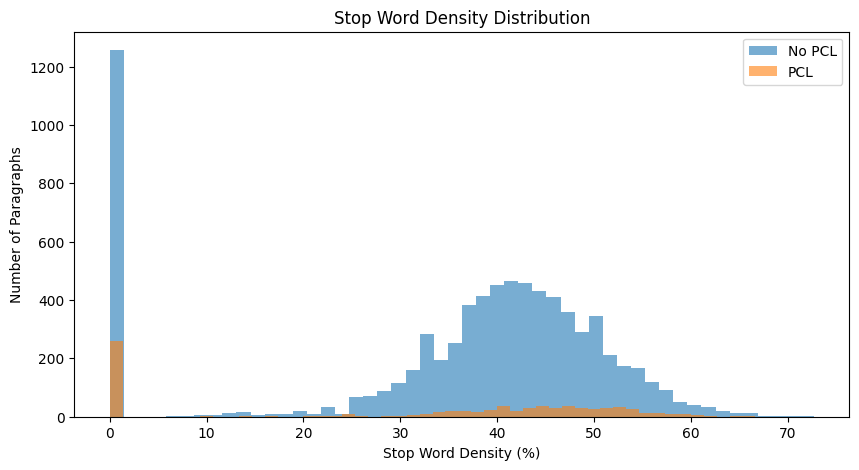


===== WORD CLOUDS & FREQUENCY =====


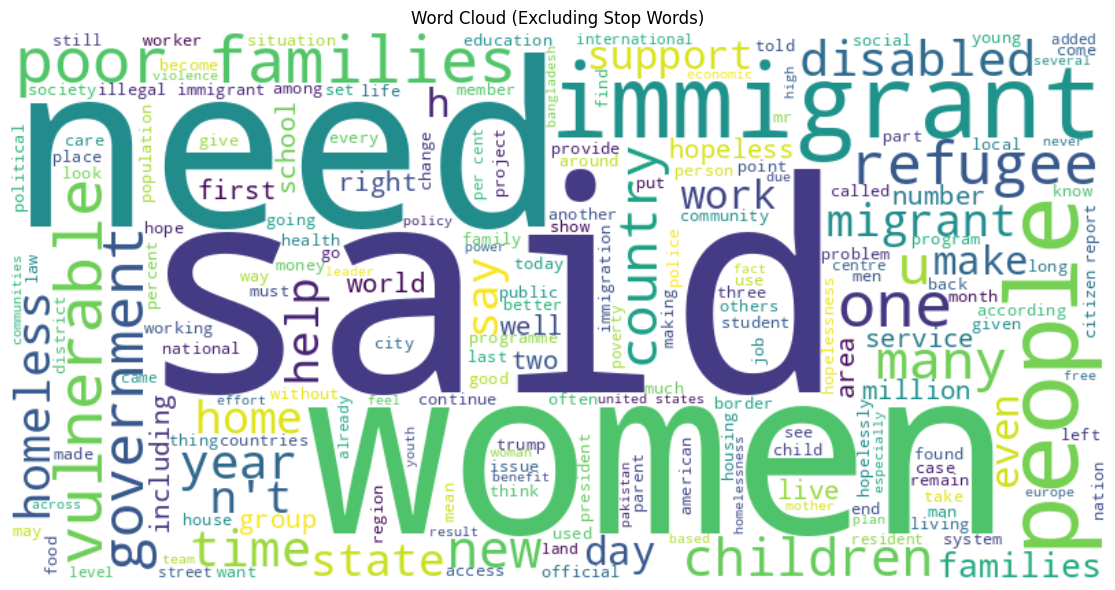

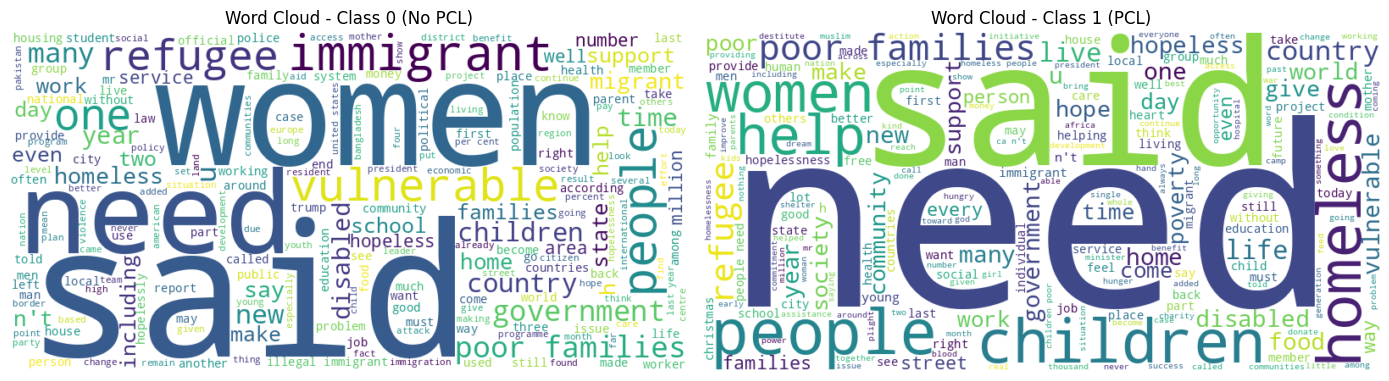

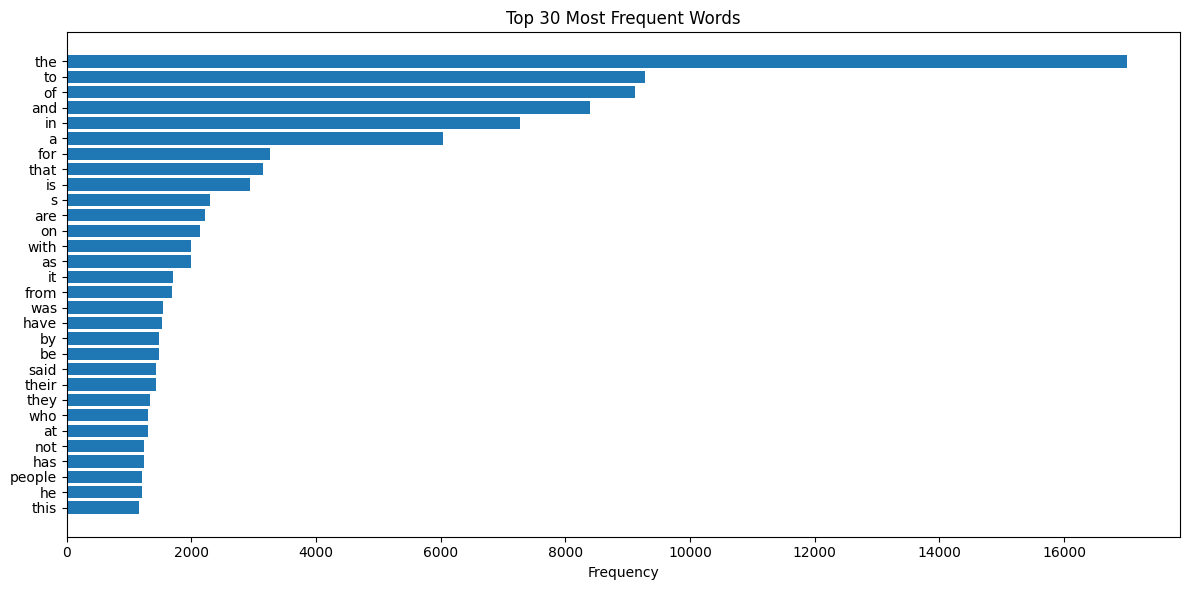


Top 30 Words (including stop words):
[('the', 17011), ('to', 9276), ('of', 9112), ('and', 8397), ('in', 7267), ('a', 6028), ('for', 3263), ('that', 3148), ('is', 2932), ('s', 2303), ('are', 2224), ('on', 2133), ('with', 1992), ('as', 1990), ('it', 1703), ('from', 1692), ('was', 1535), ('have', 1530), ('by', 1482), ('be', 1480), ('said', 1435), ('their', 1432), ('they', 1329), ('who', 1305), ('at', 1300), ('not', 1246), ('has', 1240), ('people', 1208), ('he', 1208), ('this', 1153)]

Top 30 Words (excluding stop words):
[('said', 1435), ('people', 1208), ('women', 1068), ('need', 874), ('families', 865), ('immigrants', 863), ('vulnerable', 784), ('poor', 776), ('disabled', 744), ('homeless', 674), ('refugees', 638), ('one', 637), ('also', 635), ('children', 633), ('would', 551), ('government', 550), ('new', 548), ('many', 513), ('country', 506), ('year', 484), ("n't", 473), ('us', 415), ('immigrant', 382), ('time', 367), ('refugee', 348), ('help', 342), ('h', 341), ('hopeless', 341), ('

In [4]:
import pandas as pd
import numpy as np
import re
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.util import ngrams

# Download required NLTK resources
nltk.download('stopwords')

# Load dataset
df = pd.read_csv('merged_pcl_dataset.csv')
df['y'] = (df['final_label'] >= 1).astype(int)

# Create a column for tokenized text
TOKEN_RE = re.compile(r"[a-z]+(?:'[a-z]+)?")

def tokenize(text):
    if not isinstance(text, str):
        return []
    return TOKEN_RE.findall(text.lower())

df['tokens'] = df['text'].apply(tokenize)

# Get English stop words
stop_words = set(stopwords.words('english'))

######## N-GRAM ANALYSIS #######

def get_ngrams(tokens, n):
    """Extract n-grams from token list"""
    return list(ngrams(tokens, n))

# Get all bigrams and trigrams
all_tokens = [token for tokens in df['tokens'] for token in tokens]
all_bigrams = [bigram for tokens in df['tokens'] for bigram in get_ngrams(tokens, 2)]
all_trigrams = [trigram for tokens in df['tokens'] for trigram in get_ngrams(tokens, 3)]

bigram_counts = Counter(all_bigrams)
trigram_counts = Counter(all_trigrams)

print("\n===== N-GRAM ANALYSIS =====")
print("\nTop 20 Bigrams:")
print(bigram_counts.most_common(20))

print("\nTop 20 Trigrams:")
print(trigram_counts.most_common(20))

# By class
print("\n--- Bigrams by Class ---")
class_0_bigrams = [bigram for tokens, label in zip(df['tokens'], df['y']) if label == 0
                    for bigram in get_ngrams(tokens, 2)]
class_1_bigrams = [bigram for tokens, label in zip(df['tokens'], df['y']) if label == 1
                    for bigram in get_ngrams(tokens, 2)]

class_0_bigram_counts = Counter(class_0_bigrams)
class_1_bigram_counts = Counter(class_1_bigrams)

print("\nTop 15 Bigrams (Class 0 - No PCL):")
print(class_0_bigram_counts.most_common(15))

print("\nTop 15 Bigrams (Class 1 - PCL):")
print(class_1_bigram_counts.most_common(15))

######## STOP WORD DENSITY #######

print("\n===== STOP WORD DENSITY =====")

def calculate_stop_word_density(tokens):
    """Calculate percentage of stop words in token list"""
    if len(tokens) == 0:
        return 0
    stop_word_count = sum(1 for token in tokens if token in stop_words)
    return (stop_word_count / len(tokens)) * 100

df['stop_word_density'] = df['tokens'].apply(calculate_stop_word_density)

print(f"\nOverall Stop Word Density:")
print(f"  Mean: {df['stop_word_density'].mean():.2f}%")
print(f"  Median: {df['stop_word_density'].median():.2f}%")
print(f"  Min: {df['stop_word_density'].min():.2f}%")
print(f"  Max: {df['stop_word_density'].max():.2f}%")

print(f"\nStop Word Density by Class:")
print(f"  Class 0 (No PCL) - Mean: {df[df['y']==0]['stop_word_density'].mean():.2f}%")
print(f"  Class 1 (PCL) - Mean: {df[df['y']==1]['stop_word_density'].mean():.2f}%")

# Visualize stop word density distribution
plt.figure(figsize=(10, 5))
plt.hist(df[df['y']==0]['stop_word_density'], bins=50, alpha=0.6, label='No PCL')
plt.hist(df[df['y']==1]['stop_word_density'], bins=50, alpha=0.6, label='PCL')
plt.xlabel('Stop Word Density (%)')
plt.ylabel('Number of Paragraphs')
plt.title('Stop Word Density Distribution')
plt.legend()
plt.savefig('stop_word_density.pdf')
plt.show()

######## WORD CLOUDS & FREQUENCY #######

print("\n===== WORD CLOUDS & FREQUENCY =====")

# Overall word cloud
all_text = ' '.join([token for tokens in df['tokens'] for token in tokens if token not in stop_words])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud (Excluding Stop Words)')
plt.tight_layout()
plt.savefig('wordcloud_all.pdf')
plt.show()

# Word cloud by class
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Class 0
class_0_text = ' '.join([token for tokens, label in zip(df['tokens'], df['y']) if label == 0
                          for token in tokens if token not in stop_words])
wordcloud_0 = WordCloud(width=800, height=400, background_color='white').generate(class_0_text)
axes[0].imshow(wordcloud_0, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Word Cloud - Class 0 (No PCL)')

# Class 1
class_1_text = ' '.join([token for tokens, label in zip(df['tokens'], df['y']) if label == 1
                          for token in tokens if token not in stop_words])
wordcloud_1 = WordCloud(width=800, height=400, background_color='white').generate(class_1_text)
axes[1].imshow(wordcloud_1, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Word Cloud - Class 1 (PCL)')

plt.tight_layout()
plt.savefig('wordcloud_by_class.pdf')
plt.show()

# Word frequency (top 30)
fig, ax = plt.subplots(figsize=(12, 6))
top_30_tokens = Counter(all_tokens).most_common(30)
tokens_only, freqs = zip(*top_30_tokens)
ax.barh(range(len(tokens_only)), freqs)
ax.set_yticks(range(len(tokens_only)))
ax.set_yticklabels(tokens_only)
ax.invert_yaxis()
ax.set_xlabel('Frequency')
ax.set_title('Top 30 Most Frequent Words')
plt.tight_layout()
plt.savefig('top_30_words.pdf')
plt.show()

print("\nTop 30 Words (including stop words):")
print(Counter(all_tokens).most_common(30))

print("\nTop 30 Words (excluding stop words):")
non_stop_tokens = [token for token in all_tokens if token not in stop_words]
print(Counter(non_stop_tokens).most_common(30))

In [5]:
import pandas as pd
df = pd.read_csv("merged_pcl_dataset.csv")
print(df.columns)
print(df["final_label"].value_counts())
print(df["text"].head(2).to_list())

Index(['par_id', 'semeval_id', 'keyword', 'country_code', 'text',
       'final_label'],
      dtype='object')
final_label
0    7581
1     794
Name: count, dtype: int64
['The scheme saw an estimated 150,000 children from poor families being sent to parts of the British Empire between 1920 and 1974 , by religious orders and charities who said they would lead better lives .', "Durban 's homeless communities reconciliation lunch"]


In [6]:
import numpy as np

# Load dev labels
dev_labels = pd.read_csv('datasets/dev_semeval_parids-labels.csv')  # adjust if name differs
dev_labels['par_id'] = dev_labels['par_id'].astype(int)

# Find label column name automatically
label_candidates = [c for c in dev_labels.columns if c.lower() in ['label', 'labels', 'y', 'final_label']]
if not label_candidates:
    raise ValueError(f"Couldn't find label column in dev file. Columns: {dev_labels.columns.tolist()}")
DEV_LABEL_COL = label_candidates[0]
print("Using dev label column:", DEV_LABEL_COL)

# Convert to binary
def to_binary(x):
    if pd.isna(x): return 0
    try:
        v = ast.literal_eval(str(x))
        if isinstance(v, list):
            return 1 if 1 in v else 0
    except:
        pass
    try:
        return int(x)
    except:
        return 0

dev_labels['y'] = dev_labels[DEV_LABEL_COL].apply(to_binary).astype(int)

# Join to text
df_x_text = df_x[['par_id', 'text']].copy()
dev_df = dev_labels.merge(df_x_text, on='par_id', how='left')
dev_df['text'] = dev_df['text'].astype(str).fillna("")

print(dev_df.head())
print("Dev label dist:", dev_df['y'].value_counts().to_dict())
print("Missing dev texts:", (dev_df['text'].str.len() == 0).sum())

Using dev label column: label
   par_id                  label  y  \
0    4046  [1, 0, 0, 1, 0, 0, 0]  1   
1    1279  [0, 1, 0, 0, 0, 0, 0]  1   
2    8330  [0, 0, 1, 0, 0, 0, 0]  1   
3    4063  [1, 0, 0, 1, 1, 1, 0]  1   
4    4089  [1, 0, 0, 0, 0, 0, 0]  1   

                                                text  
0  We also know that they can benefit by receivin...  
1  Pope Francis washed and kissed the feet of Mus...  
2                                                nan  
3  Budding chefs , like " Fred " , " Winston " an...  
4  In a 90-degree view of his constituency , one ...  
Dev label dist: {0: 1895, 1: 199}
Missing dev texts: 0


In [7]:
!pip -q install -U "transformers==4.44.2" "accelerate" "scikit-learn"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 82.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 92.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 78.8 MB/s eta 0:00:00


In [8]:
!pip -q uninstall -y pyarrow

In [11]:
import torch
import pandas as pd
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

df = pd.read_csv("merged_pcl_dataset.csv")
df["final_label"] = df["final_label"].astype(int)
df["text"] = df["text"].astype(str).fillna("")

train_df, val_df = train_test_split(
    df, test_size=0.1, random_state=42, stratify=df["final_label"]
)

# dev_df must exist from your earlier dev join cell
assert "dev_df" in globals(), "Run the dev_df construction cell first."
assert "text" in dev_df.columns and "y" in dev_df.columns
dev_df["y"] = dev_df["y"].astype(int)
dev_df["text"] = dev_df["text"].astype(str).fillna("")

Device: cuda


In [13]:
import numpy as np
import pandas as pd
import torch
import ast

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_recall_fscore_support

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
    set_seed
)

set_seed(42)
print("Imports successful")

Imports successful


In [14]:
MODEL_NAME = "bert-base-uncased"
MAX_LEN = 128
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

class TextDataset(Dataset):
    def __init__(self, frame, text_col="text", label_col=None):
        self.frame = frame.reset_index(drop=True)
        self.text_col = text_col
        self.label_col = label_col

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        text = self.frame.loc[idx, self.text_col]
        enc = tokenizer(
            text,
            truncation=True,
            max_length=MAX_LEN,
            return_tensors="pt"
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        if self.label_col is not None:
            item["labels"] = torch.tensor(int(self.frame.loc[idx, self.label_col]), dtype=torch.long)
        return item

train_ds = TextDataset(train_df, label_col="final_label")
val_ds   = TextDataset(val_df, label_col="final_label")
dev_ds   = TextDataset(dev_df, label_col="y")

def collate_fn(batch):
    # pad to max length in batch
    input_ids = [x["input_ids"] for x in batch]
    attention_mask = [x["attention_mask"] for x in batch]
    labels = [x["labels"] for x in batch] if "labels" in batch[0] else None

    padded = tokenizer.pad(
        {"input_ids": input_ids, "attention_mask": attention_mask},
        padding=True,
        return_tensors="pt"
    )
    if labels is not None:
        padded["labels"] = torch.stack(labels)
    return padded

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [15]:
n_pos = int((train_df["final_label"] == 1).sum())
n_neg = int((train_df["final_label"] == 0).sum())
w_pos = n_neg / max(1, n_pos)
class_weights = torch.tensor([1.0, float(w_pos)], dtype=torch.float, device=device)
print("n_neg:", n_neg, "n_pos:", n_pos, "w_pos:", w_pos)

loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)

n_neg: 6822 n_pos: 715 w_pos: 9.54125874125874


In [16]:
BATCH_SIZE = 16   # if CPU is slow use 8
EPOCHS = 3        # start with 2-3
LR = 2e-5

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, collate_fn=collate_fn)
dev_loader   = DataLoader(dev_ds, batch_size=32, shuffle=False, collate_fn=collate_fn)

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

def eval_pos_f1(loader, threshold=0.5):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            labels = batch["labels"].numpy()
            batch = {k: v.to(device) for k, v in batch.items() if k != "labels"}
            logits = model(**batch).logits
            probs = torch.softmax(logits, dim=-1)[:, 1].cpu().numpy()
            all_probs.append(probs)
            all_labels.append(labels)
    probs = np.concatenate(all_probs)
    labels = np.concatenate(all_labels)
    preds = (probs >= threshold).astype(int)
    return f1_score(labels, preds, pos_label=1), probs, labels

best_val_f1 = -1
best_state = None

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0

    for batch in train_loader:
        labels = batch["labels"].to(device)
        inputs = {k: v.to(device) for k, v in batch.items() if k != "labels"}

        optimizer.zero_grad()
        logits = model(**inputs).logits
        loss = loss_fn(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    val_f1, _, _ = eval_pos_f1(val_loader, threshold=0.5)
    print(f"Epoch {epoch} | train_loss={total_loss/len(train_loader):.4f} | val_pos_f1@0.5={val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

# load best
model.load_state_dict(best_state)
model.to(device)
print("Best val pos_f1@0.5:", best_val_f1)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Epoch 1 | train_loss=0.6115 | val_pos_f1@0.5=0.3269
Epoch 2 | train_loss=0.4884 | val_pos_f1@0.5=0.3068
Epoch 3 | train_loss=0.3619 | val_pos_f1@0.5=0.3385
Best val pos_f1@0.5: 0.3384615384615385


In [17]:
# Get dev probs
dev_f1_05, dev_probs, dev_labels = eval_pos_f1(dev_loader, threshold=0.5)
print("Dev pos_f1@0.5:", dev_f1_05)

best_t, best_f1 = 0.5, -1.0
for t in np.arange(0.05, 0.96, 0.01):
    preds = (dev_probs >= t).astype(int)
    f1 = f1_score(dev_labels, preds, pos_label=1)
    if f1 > best_f1:
        best_f1 = f1
        best_t = float(t)

best_preds = (dev_probs >= best_t).astype(int)
p, r, f1, _ = precision_recall_fscore_support(dev_labels, best_preds, pos_label=1, average="binary")

print(f"Best threshold: {best_t:.2f}")
print(f"Dev Pos-F1: {f1:.4f} | Precision: {p:.4f} | Recall: {r:.4f}")

with open("dev.txt", "w") as f:
    for v in best_preds:
        f.write(f"{int(v)}\n")

print("Wrote dev.txt")

Dev pos_f1@0.5: 0.5313653136531366
Best threshold: 0.35
Dev Pos-F1: 0.5474 | Precision: 1.0000 | Recall: 0.3769
Wrote dev.txt


In [ ]:
import numpy as np
import pandas as pd
import torch
import ast

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_recall_fscore_support

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
    set_seed
)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ----------------------------
# Load train (merged) + build dev_df (join labels to text)
# ----------------------------
df = pd.read_csv("merged_pcl_dataset.csv")
df["final_label"] = df["final_label"].astype(int)
df["text"] = df["text"].astype(str).fillna("")

# Master TSV with text
columns_x = ['par_id', 'semeval_id', 'keyword', 'country_code', 'text', 'original_label']
df_x = pd.read_csv('datasets/dontpatronizeme_pcl.tsv',
                   sep='\t', header=None, names=columns_x, skiprows=4)
df_x['par_id'] = df_x['par_id'].astype(str).str.replace('@@', '', regex=False).astype(int)

# Dev labels
dev_labels = pd.read_csv('datasets/dev_semeval_parids-labels.csv')  # adjust filename if needed
dev_labels['par_id'] = dev_labels['par_id'].astype(int)

label_candidates = [c for c in dev_labels.columns if 'label' in c.lower() or c.lower() in ['y','final_label']]
if not label_candidates:
    raise ValueError(f"No label column found in dev file. Columns: {dev_labels.columns.tolist()}")
label_col = label_candidates[0]
print("Using dev label column:", label_col)

def to_binary(x):
    if pd.isna(x): return 0
    try:
        v = ast.literal_eval(str(x))
        if isinstance(v, list):
            return 1 if 1 in v else 0
    except:
        pass
    try:
        return int(x)
    except:
        return 0

dev_labels['y'] = dev_labels[label_col].apply(to_binary).astype(int)
dev_df = dev_labels.merge(df_x[['par_id','text']], on='par_id', how='left')
dev_df['text'] = dev_df['text'].astype(str).fillna("")

print("Train dist:", df["final_label"].value_counts().to_dict())
print("Dev dist:", dev_df["y"].value_counts().to_dict())

# Train/val split (internal)
train_df, val_df = train_test_split(
    df, test_size=0.1, random_state=42, stratify=df["final_label"]
)

# ----------------------------
# Tokenizer + Dataset
# ----------------------------
MODEL_NAME = "bert-base-uncased"
MAX_LEN = 128
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

class TextDataset(Dataset):
    def __init__(self, frame, label_col):
        self.frame = frame.reset_index(drop=True)
        self.label_col = label_col
    def __len__(self):
        return len(self.frame)
    def __getitem__(self, idx):
        text = self.frame.loc[idx, "text"]
        enc = tokenizer(text, truncation=True, max_length=MAX_LEN, return_tensors="pt")
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(int(self.frame.loc[idx, self.label_col]), dtype=torch.long)
        return item

def collate_fn(batch):
    input_ids = [x["input_ids"] for x in batch]
    attention_mask = [x["attention_mask"] for x in batch]
    labels = torch.stack([x["labels"] for x in batch])
    padded = tokenizer.pad(
        {"input_ids": input_ids, "attention_mask": attention_mask},
        padding=True,
        return_tensors="pt"
    )
    padded["labels"] = labels
    return padded

train_ds = TextDataset(train_df, "final_label")
val_ds   = TextDataset(val_df, "final_label")
dev_ds   = TextDataset(dev_df, "y")

BATCH_SIZE = 16 if device.type == "cuda" else 8
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, collate_fn=collate_fn)
dev_loader   = DataLoader(dev_ds, batch_size=32, shuffle=False, collate_fn=collate_fn)

# ----------------------------
# Helpers
# ----------------------------
def predict_probs(model, loader):
    model.eval()
    probs_list, labels_list = [], []
    with torch.no_grad():
        for batch in loader:
            labels = batch["labels"].cpu().numpy()
            inputs = {k: v.to(device) for k, v in batch.items() if k != "labels"}
            logits = model(**inputs).logits
            probs = torch.softmax(logits, dim=-1)[:, 1].cpu().numpy()
            probs_list.append(probs)
            labels_list.append(labels)
    return np.concatenate(probs_list), np.concatenate(labels_list)

def tune_threshold(probs, labels):
    best_t, best_f1 = 0.5, -1.0
    for t in np.arange(0.05, 0.96, 0.01):
        preds = (probs >= t).astype(int)
        f1 = f1_score(labels, preds, pos_label=1)
        if f1 > best_f1:
            best_f1 = f1
            best_t = float(t)
    best_preds = (probs >= best_t).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(labels, best_preds, pos_label=1, average="binary")
    return best_t, f1, p, r

def train_one_run(use_class_weights: bool, epochs: int = 3, lr: float = 2e-5):
    # model
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)

    # loss
    if use_class_weights:
        n_pos = int((train_df["final_label"] == 1).sum())
        n_neg = int((train_df["final_label"] == 0).sum())
        w_pos = n_neg / max(1, n_pos)
        class_weights = torch.tensor([1.0, float(w_pos)], dtype=torch.float, device=device)
        loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)
    else:
        loss_fn = torch.nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps
    )

    # train
    best_val_f1 = -1
    best_state = None

    for ep in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        for batch in train_loader:
            labels = batch["labels"].to(device)
            inputs = {k: v.to(device) for k, v in batch.items() if k != "labels"}
            optimizer.zero_grad()
            logits = model(**inputs).logits
            loss = loss_fn(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            total_loss += loss.item()

        # internal val @0.5 (for stability)
        val_probs, val_labels = predict_probs(model, val_loader)
        val_preds = (val_probs >= 0.5).astype(int)
        val_f1 = f1_score(val_labels, val_preds, pos_label=1)
        print(f"  Epoch {ep}/{epochs} | loss={total_loss/len(train_loader):.4f} | val_pos_f1@0.5={val_f1:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    model.to(device)

    # dev metrics
    dev_probs, dev_labels = predict_probs(model, dev_loader)
    dev_f1_05 = f1_score(dev_labels, (dev_probs >= 0.5).astype(int), pos_label=1)
    t, best_f1, p, r = tune_threshold(dev_probs, dev_labels)

    return {
        "weighted_loss": use_class_weights,
        "dev_pos_f1@0.5": float(dev_f1_05),
        "best_t": float(t),
        "dev_best_pos_f1": float(best_f1),
        "precision@best_t": float(p),
        "recall@best_t": float(r),
    }

# ----------------------------
# Run ablation
# ----------------------------
EPOCHS = 3  # if CPU and slow, set to 2 for the ablation
print("\n=== Run A: Baseline (unweighted loss) ===")
res_base = train_one_run(use_class_weights=False, epochs=EPOCHS)

print("\n=== Run B: BestModel (weighted loss) ===")
res_weighted = train_one_run(use_class_weights=True, epochs=EPOCHS)

results = pd.DataFrame([res_base, res_weighted])
results["run"] = results["weighted_loss"].map({False: "Baseline", True: "WeightedLoss"})
results = results[["run", "dev_pos_f1@0.5", "best_t", "dev_best_pos_f1", "precision@best_t", "recall@best_t"]]
print("\n=== Ablation Results (Dev) ===")
display(results)

Device: cuda
Using dev label column: label
Train dist: {0: 7581, 1: 794}
Dev dist: {0: 1895, 1: 199}


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(



=== Run A: Baseline (unweighted loss) ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


  Epoch 1/3 | loss=0.3125 | val_pos_f1@0.5=0.3548
